# Ligand-Receptor Interaction Correlation (LRIC)


In this tutorial, we introduce LRIC, a weighted second-order spatial statistic in which pairwise contributions are weighted by ligand and receptor expression levels across a range of distances (annuli). 

LRIC builds on the cross pair-correlation function (cross-PCF; see also [Baddeley et al., 2016](https://www.jstatsoft.org/htaccess.php?volume=075&type=b&issue=02&filename=paper) and [Bull et al., 2024](https://www.biorxiv.org/content/10.1101/2024.12.06.627195)) by additionally weighting every cell by its ligand and receptor expression.
<br>

<img src="LRIC_summary.png" width=1000 />

## Environement Setup

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import scanpy as sc
import liana as li

## Load and Normalize Data

To demonstrate the LRIC in practice, we will apply it to a spatial transcriptomics dataset from [A molecularly defined and spatially resolved cell atlas of the whole mouse brain(Nature, 2023)](https://www.nature.com/articles/s41586-023-06808-9); [WB_MERFISH_animal2_coronal](https://cellxgene.cziscience.com/collections/0cca8620-8dee-45d0-aef5-23f032a5cf09).

The dataset was generated using **MERFISH** technique, which enables highly multiplexed single-molecule RNA imaging with subcellular spatial resolution. This dataset profiles the expression of more than **1,000** genes across roughly **10 million cells** in the adult **mouse brain**.

In [2]:
file_path  = "data/MERFISH_mouse_brain/WB_MERFISH_animal2_coronal.h5ad"
backup_url = "https://datasets.cellxgene.cziscience.com/93c3bb97-ea05-4ee0-a760-a1508cd04612.h5ad"

adata = sc.read(file_path) if os.path.exists(file_path) else sc.read(file_path, backup_url=backup_url)

# Subset to one brain section
adata = adata[adata.obs["brain_section_label"] == "C57BL6J-2.039"]
# The dataset indexes vars by Ensembl ID; switch to gene symbols for LR lookup
adata.var_names = adata.var["gene_name"]

# Basic QC
sc.pp.filter_cells(adata, min_genes=10)
sc.pp.filter_genes(adata, min_cells=3)

# Normalise (keep raw counts in a layer); LRIC will use normalised log1p values
adata.layers["counts"] = adata.X.copy()
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

# Spatial coordinates are in µm (MERFISH physical units)
print(adata)


AnnData object with n_obs × n_vars = 51539 × 1120
    obs: 'donor_id', 'development_stage_ontology_term_id', 'sex_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'disease_ontology_term_id', 'tissue_ontology_term_id', 'cell_type_ontology_term_id', 'assay_ontology_term_id', 'suspension_type', 'cluster_id_transfer', 'subclass_transfer', 'cluster_confidence_score', 'subclass_confidence_score', 'high_quality_transfer', 'major_brain_region', 'ccf_region_name', 'brain_section_label', 'tissue_type', 'is_primary_data', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid', 'n_genes'
    var: 'gene_name', 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type', 'n_cells'
    uns: 'citation', 'organism', 'organism_ontology_term_id', 'schema_reference', 'schema_version', 'title', 'log1p'
    obsm: 'X_CCF', 'X_spatial_coords', 'X_umap'
    layers: 'counts'


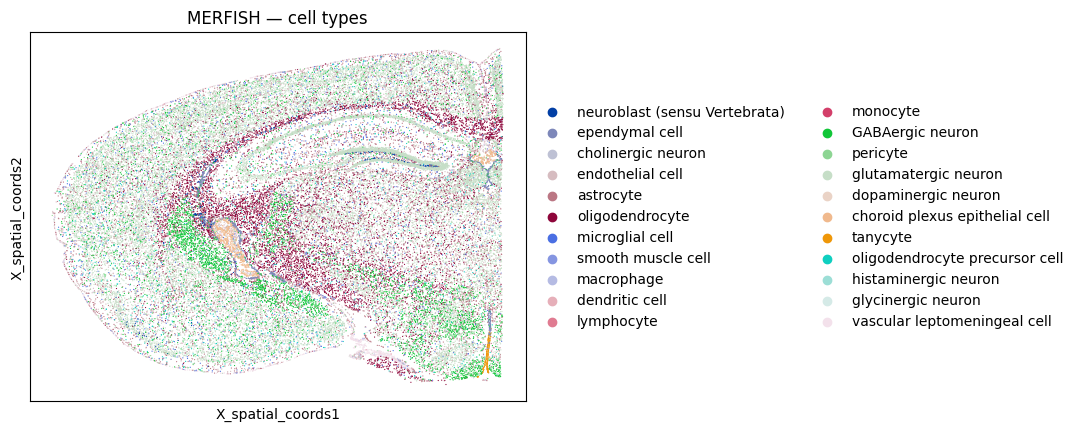

In [3]:
sc.pl.embedding(
    adata, basis="X_spatial_coords",
    color="cell_type", s=3, title="MERFISH — cell types"
)

## Ligand–Receptor Database (mouse)

In [4]:
resource = li.rs.select_resource('mouseconsensus')
print(f"{len(resource)} LR pairs in resource")
resource.head(5)

3989 LR pairs in resource


,ligand,receptor
31371,Dll1,Notch1
31372,Dll1,Notch2
31373,Dll1,Notch4
31374,Dll1,Notch3
31375,Nrg2,Erbb2_Erbb3


## Cross-PCF: Baseline Spatial Structure

Cross-PCF answers a **purely spatial** question:

> Are cells of type B more (or less) frequent around cells of type A at distance r than expected under complete spatial randomness?

It treats all cells **equally**. Gene expression is not considered. We use it to characterise the raw spatial architecture of the tissue before asking about LR interactions.

### Choose the right parameters
All distance parameters are in the same units as the spatial coordinates **µm** for this MERFISH dataset. <br>
**radius_step** = step between bin inner edges (e.g. 20-25 µm, the typical upper bound of the diameter of generic cells; though this might vary a lot depending on the tissue and cell types!). <br>
**annulus_width** = radial width of each annulus ring. <br>
Setting `annulus_width = radius_step` ensures bins are non-overlapping and tile the full range without gaps. <br>
**max_radius** = inner edge of the last (widest) bin; the outer edge extends to `max_radius + annulus_width`. <br>

In [5]:
annulus_width = 25

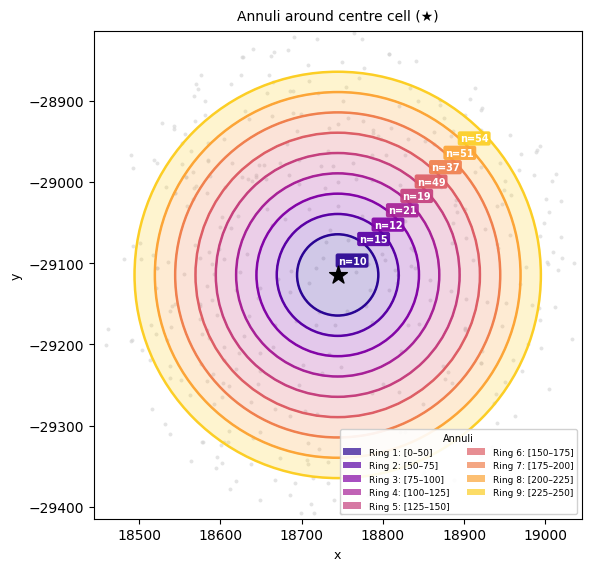

In [6]:
li.pl.annulus_plot(
    adata,
    spatial_key="X_spatial_coords",
    annulus_width=annulus_width,
    radius_step=annulus_width,
    n_rings=9,
    seed=5,
    figure_size= (6, 6))

Note that, by default (`extend_first_annulus=True`), the innermost `[0, radius_step)` contact band is merged **into the first annulus**, which therefore spans `[0, radius_step + annulus_width)` and starts at radius 0. Distances are measured from each **focal cell's centroid**, so cell centroids cannot lie closer than ~one cell diameter; the innermost band is otherwise a thin, near-empty, high-variance bin. Merging it folds genuine cell–cell contact pairs into the first bin instead of discarding them. Set `extend_first_annulus=False` to keep the first ring at `[radius_step, radius_step + annulus_width)`.

### Cross-PCF 

In [7]:
li.mt.cross_pcf(
    adata,
    groupby="cell_type",
    spatial_key="X_spatial_coords",
    max_radius=200,
    radius_step=annulus_width,
    annulus_width=annulus_width,
    min_cells=50,
    key_added="cross_pcf", #results will be saved under this label in adata.uns
    verbose=True,
)

Dropping 7 cell type(s) with fewer than 50 cells: ['cholinergic neuron', 'dendritic cell', 'dopaminergic neuron', 'glycinergic neuron', 'histaminergic neuron', 'lymphocyte', 'monocyte']
Computing cross-PCF for 15 cell types (210 directed pairs).
cross-PCF: 100%|██████████| 210/210 [00:21<00:00,  9.55it/s]


#### Aggregation: cells cluster together at a short distance

We will find cross-pcf results for **Pericytes** and **vascular leptomeningeal cells (VLMCs)**, both are vascular support cell types associated with the perivascular niche and are expected to show spatial co-localisation along blood vessels.

In [8]:
cpcf = adata.uns["cross_pcf"]
r = np.asarray(cpcf["radii"], dtype=float)

In [9]:
snd, rcv = "pericyte", "vascular leptomeningeal cell"
crosspcf = np.asarray(cpcf["results"][(snd, rcv)], dtype=float)

We reuse the same two-panel summary throughout this section, so we wrap it in a small helper. `plot_pair` draws the spatial layout of a sender→receiver pair on the left and overlays their g(r) curve(s) on the right; optionally passing `ligand`/`receptor` annotates the legend with the fraction of each population expressing them.

In [10]:
def plot_pair(snd, rcv, curves, colors=None, title=None,
              ligand=None, receptor=None, spatial_key="X_spatial_coords"):
    """Two-panel summary for a sender -> receiver cell-type pair.

    Left: spatial map of the sender (green) and receiver (orange) cells over
    the rest of the tissue (grey). Right: the supplied g(r) curve(s) drawn with
    ``li.pl.lric_lineplot`` — ``curves`` maps each label to an ``(radii, g)``
    tuple. If ``ligand``/``receptor`` are given, the legend also reports the
    percentage of each population expressing them.
    """
    coords = adata.obsm[spatial_key]
    ct = adata.obs["cell_type"].astype(str).values
    snd_mask, rcv_mask = ct == snd, ct == rcv
    other_mask = ~(snd_mask | rcv_mask)

    snd_lab = f"{snd}  (sender, n={snd_mask.sum():,})"
    rcv_lab = f"{rcv}  (receiver, n={rcv_mask.sum():,})"
    if ligand is not None and receptor is not None:
        snd_pct = 100 * (adata[:, ligand].X.toarray()[snd_mask] > 0).mean()
        rcv_pct = 100 * (adata[:, receptor].X.toarray()[rcv_mask] > 0).mean()
        snd_lab = f"{snd}  (n={snd_mask.sum():,},  {ligand}+ {snd_pct:.1f}%)"
        rcv_lab = f"{rcv}  (n={rcv_mask.sum():,},  {receptor}+ {rcv_pct:.1f}%)"

    fig, axes = plt.subplots(1, 2, figsize=(13, 5), layout="constrained",
                             gridspec_kw={"width_ratios": [1.1, 1.0]})
    ax0 = axes[0]
    ax0.scatter(coords[other_mask, 0], coords[other_mask, 1],
                s=2, c="lightgray", alpha=0.1, linewidths=0, rasterized=True)
    # receiver first, sender on top so the sender layer is not buried
    ax0.scatter(coords[rcv_mask, 0], coords[rcv_mask, 1],
                s=6, c="tab:orange", alpha=0.6, linewidths=0, rasterized=True, label=rcv_lab)
    ax0.scatter(coords[snd_mask, 0], coords[snd_mask, 1],
                s=10, c="tab:green", alpha=0.9, linewidths=0, rasterized=True, label=snd_lab)
    ax0.set_aspect("equal"); ax0.axis("off")
    ax0.set_title("Spatial distribution")
    ax0.legend(frameon=False, fontsize=9, loc="upper left",
               bbox_to_anchor=(0, -0.02), ncol=1)

    li.pl.lric_lineplot(None, curves, overlay=True, colors=colors, title=title, ax=axes[1])
    plt.show()

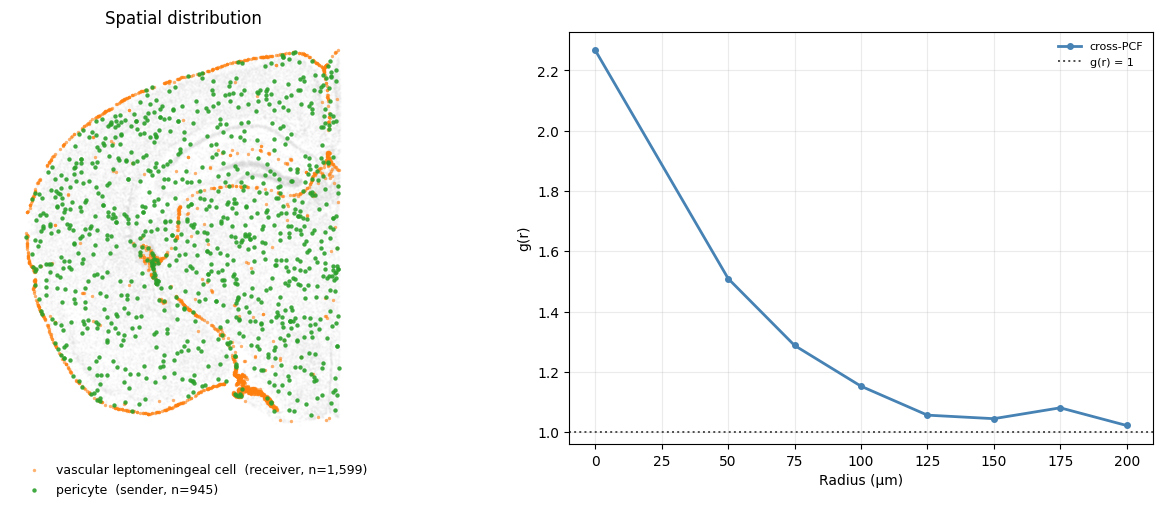

In [11]:
plot_pair(snd, rcv, {"cross-PCF": (r, crosspcf)}, colors="steelblue")

#### Exclusion: cells avoid each other

**Choroid plexus epithelial cells** are largely confined to the ventricular choroid plexus, while **glutamatergic neurons** are distributed throughout the brain parenchyma. Because these cell types occupy largely non-overlapping spatial domains, the observed cross-pair correlation function g(r) < 1 primarily reflects spatial compartmentalization.

In [12]:
snd, rcv = "choroid plexus epithelial cell", "glutamatergic neuron"
crosspcf = np.asarray(cpcf["results"][(snd, rcv)], dtype=float)

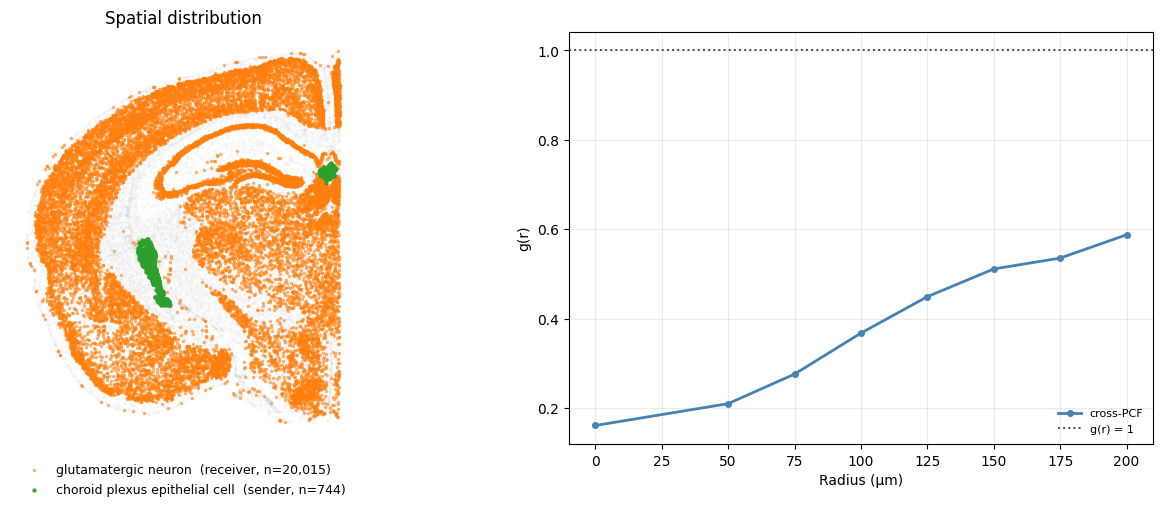

In [13]:
plot_pair(snd, rcv, {"cross-PCF": (r, crosspcf)}, colors="steelblue")

## Ligand–Receptor Global Co-expression using LRIC

The **agnostic** mode of `LRIC` answer questions like:

> Across all cells in the tissue, is the **ligand signal** spatially enriched around **receptor-expressing** receiver cells at distance r?

Here, because all cells are pooled, the signal can be inflated by tissue compartment structure, so a high agnostic score does not guarantee that the interaction is biologically directed between specific cell types.

In [14]:
li.mt.lric(
    adata,
    resource=resource,
    spatial_key="X_spatial_coords",
    max_radius=200,
    radius_step=annulus_width,
    annulus_width=annulus_width,
    use_raw=False,          
    key_added="lric_ag",  #results will be saved under this label in adata.uns
    verbose=True,
)

Using provided `resource`.


Running cell-type-agnostic LRIC.


### Rank LR Pairs by Signal 

Useful summary statistics here:
- **`mean_lric`**: average g(r) across all radii (overall spatial co-enrichment).
- **`max_lric`**: peak g(r) (strength of the strongest spatial enrichment at any distance).
- **`peak_radius`**: distance at which g(r) is highest (characteristic interaction range).

In [15]:
ag = adata.uns["lric_ag"]
L = ag["lric"]

pair_scores = (
    pd.DataFrame({
        "pair": ag["pair_names"],
        "mean_lric": L.mean(0),
        "max_lric": L.max(0),
        "peak_radius": ag["radii"][L.argmax(0)],
    })
    .assign(max_minus_mean=lambda d: d["max_lric"] - d["mean_lric"])
    .sort_values("max_minus_mean", ascending=False)
)

top5 = pair_scores.head(5)

print("Top 5 LR pairs by (max - mean) LRIC:")
print(top5)

Top 5 LR pairs by (max - mean) LRIC:
               pair  mean_lric  max_lric  peak_radius  max_minus_mean
63       Ntf3^Ntrk3   2.456533  3.968962          0.0        1.512429
11      Col6a5^Cd44   1.848814  2.937120          0.0        1.088306
107  Gpc3^Tnfrsf11b   1.868091  2.910218          0.0        1.042127
95       Sfrp1^Fzd2   2.213429  3.238567          0.0        1.025138
92       Tac2^Tacr1   6.347380  7.282334          0.0        0.934954


### Top pairs across distance

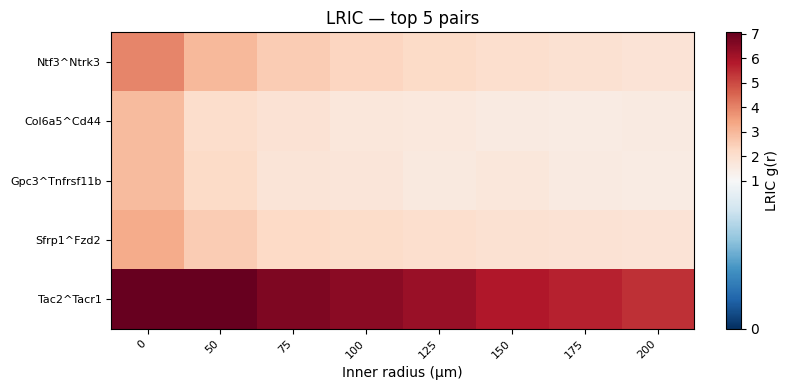

In [16]:
TOP_N = 5

top_df = pair_scores.head(TOP_N)
top_pairs = top_df["pair"].tolist()
top_idx   = top_df.index.to_list()   
top_mat   = L[:, top_idx].T          # (TOP_N, n_bins)

vmax = np.percentile(top_mat, 97)
fig, ax = plt.subplots(figsize=(8, 4))

im = ax.imshow(
    top_mat,
    aspect="auto",
    origin="upper",
    cmap="RdBu_r",
    norm=mcolors.TwoSlopeNorm(vmin=0, vcenter=1, vmax=vmax),
)

plt.colorbar(im, ax=ax, label="LRIC g(r)", fraction=0.03)
ax.set_xticks(range(len(ag["radii"])))
ax.set_xticklabels(ag["radii"].astype(int), rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(TOP_N))
ax.set_yticklabels(top_pairs, fontsize=8)
ax.set_xlabel("Inner radius (µm)")
ax.set_title(f"LRIC — top {TOP_N} pairs")
plt.tight_layout()
plt.show()

### Distance profiles for top-ranked pairs

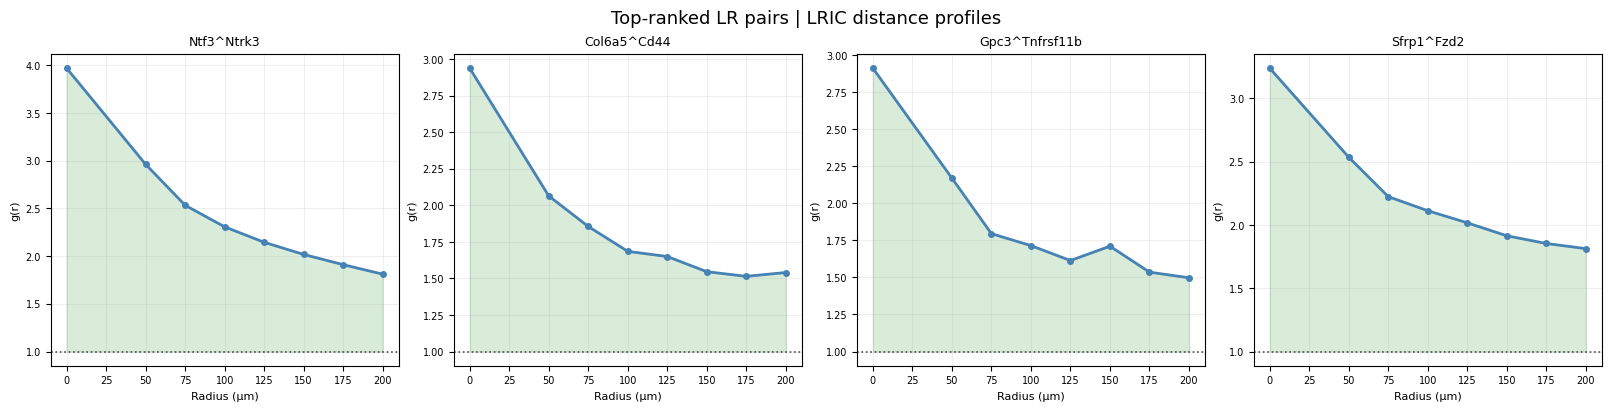

In [17]:
TOP_N = 4

top = pair_scores.head(TOP_N)["pair"].tolist()

fig, axes = plt.subplots(1, TOP_N, figsize=(4 * TOP_N, 4), layout="constrained")
for ax, pair in zip(axes.flat, top):
    idx = ag["pair_names"].index(pair)
    g   = ag["lric"][:, idx]

    ax.plot(ag["radii"], g, lw=2, marker="o", ms=4, color="steelblue")
    ax.axhline(1, linestyle=":", color="0.3", lw=1.2)
    ax.fill_between(ag["radii"], 1, g, where=g > 1, alpha=0.15, color="green")
    ax.fill_between(ag["radii"], g, 1, where=g < 1, alpha=0.15, color="red")
    ax.set_title(pair, fontsize=9)
    ax.set_xlabel("Radius (µm)", fontsize=8)
    ax.set_ylabel("g(r)", fontsize=8)
    ax.grid(alpha=0.2); ax.tick_params(labelsize=7)

fig.suptitle("Top-ranked LR pairs | LRIC distance profiles", fontsize=13)
plt.show()

## LRIC Cell-Type Informed for Directed Interactions

The **cell-type-informed** mode splits cells into sender and receiver populations by cell-type annotation and computes g(r) for every directed **(sender → receiver)** pair, weighted by the LR expression.

This answers a more specific question:

> For the specific interaction **sender cell type X expressing ligand L** → **receiver cell type Y expressing receptor R**, is the LR-weighted spatial co-enrichment at distance r higher than expected?

**Key advantage over cross-PCF**: the expression weighting means g(r) > 1 can only be driven by cells that express the relevant ligand/receptor.

In [18]:
li.mt.lric(
    adata,
    resource=resource,
    groupby="cell_type",
    spatial_key="X_spatial_coords",
    max_radius=200,
    radius_step=annulus_width,
    annulus_width=annulus_width,
    min_cells=50,
    min_expressing=20,
    use_raw=False,
    key_added="lric_ct", #results will be saved under this label in adata.uns
    verbose=True,
)

Using provided `resource`.


Dropping 7 cell type(s) with fewer than 50 cells: ['cholinergic neuron', 'dendritic cell', 'dopaminergic neuron', 'glycinergic neuron', 'histaminergic neuron', 'lymphocyte', 'monocyte']
Running LRIC for 15 cell types (210 directed pairs).
LRIC: 100%|██████████| 210/210 [00:17<00:00, 11.72it/s]


### Cross-PCF vs LRIC: Does expression add information?

Cross-PCF captures spatial structure. If LRIC tracks cross-PCF closely, the LR pair's signal is mostly explained by where the two cell types happen to be. If LRIC **exceeds** cross-PCF, the expression weighting is amplifying the signal: cells that express the ligand/receptor are not distributed randomly within their cell type but they cluster near each other.

We compare cross-PCF, agnostic LRIC, and CT-specific LRIC for **Tac2→Tacr3** (tachykinin neuropeptide signalling) on the GABAergic → glutamatergic axis.


In [19]:
snd, rcv = "GABAergic neuron", "glutamatergic neuron"
ligand, receptor =  "Tac2", "Tacr3"

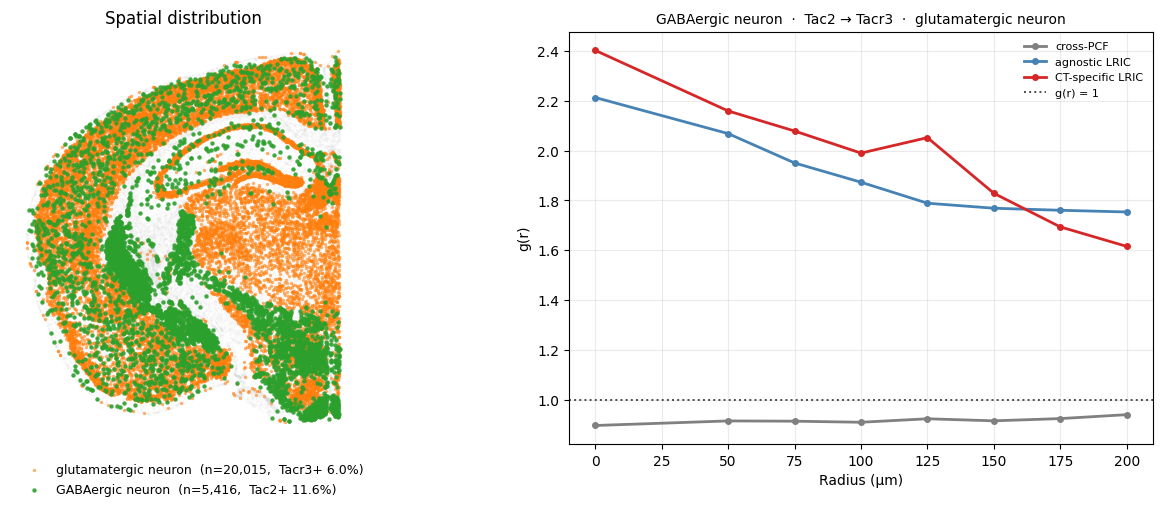

In [20]:
lric_ct = adata.uns["lric_ct"]
lr_pair = next(p for p in lric_ct["pair_names"] if ligand in p and receptor in p)

# extract g(r) curves for the three views
r_c  = np.asarray(cpcf["radii"], dtype=float)
g_c  = np.asarray(cpcf["results"].get((snd, rcv), np.full_like(r_c, np.nan)), dtype=float)

p_ag = ag["pair_names"].index(lr_pair)
r_ag = np.asarray(ag["radii"], dtype=float)
g_ag = np.asarray(ag["lric"][:, p_ag], dtype=float)

p_ct = lric_ct["pair_names"].index(lr_pair)
r_ct = np.asarray(lric_ct["radii"], dtype=float)
g_ct = np.asarray(lric_ct["results"][(snd, rcv)][:, p_ct], dtype=float)

plot_pair(
    snd, rcv,
    {"cross-PCF": (r_c, g_c), "agnostic LRIC": (r_ag, g_ag), "CT-specific LRIC": (r_ct, g_ct)},
    colors={"cross-PCF": "0.5", "agnostic LRIC": "steelblue", "CT-specific LRIC": "tab:red"},
    title=f"{snd}  ·  {ligand} → {receptor}  ·  {rcv}",
    ligand=ligand, receptor=receptor,
)

We notice that CT-specific LRIC (red) peaks above the cross-PCF (grey) at short distances. The Tac2/Tacr3 expression pattern reinforces the spatial proximity signal: GABAergic cells that express Tac2 tend to be found near glutamatergic cells that express Tacr3, beyond what the overall cell-type co-localisation would predict.

In contrast, **Efna5-expressing GABAergic** and **Epha1-expressing glutamatergic** neurons show the opposite pattern. Although the two cell types are broadly co-distributed (cross-PCF ≈ 1), the CT-specific LRIC drops below 1: cells that express these ephrin partners are specifically less likely to be near one another than the overall cell-type co-localisation would suggest.

In [21]:
snd, rcv = "GABAergic neuron", "glutamatergic neuron"
ligand, receptor =  "Efna5", "Epha1"

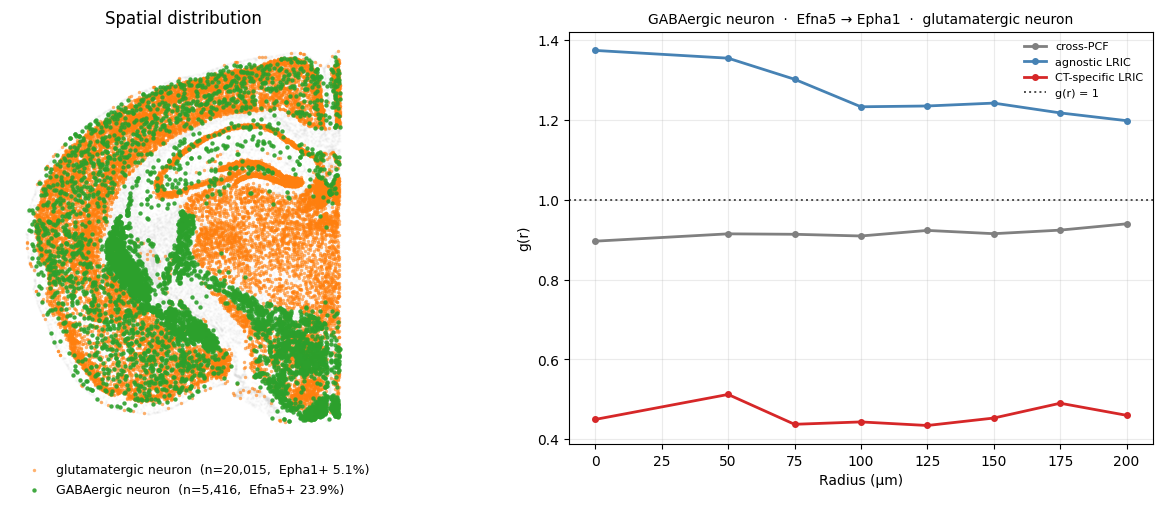

In [22]:
lric_ct = adata.uns["lric_ct"]
lr_pair = next(p for p in lric_ct["pair_names"] if ligand in p and receptor in p)

# extract g(r) curves for the three views
r_c  = np.asarray(cpcf["radii"], dtype=float)
g_c  = np.asarray(cpcf["results"].get((snd, rcv), np.full_like(r_c, np.nan)), dtype=float)

p_ag = ag["pair_names"].index(lr_pair)
r_ag = np.asarray(ag["radii"], dtype=float)
g_ag = np.asarray(ag["lric"][:, p_ag], dtype=float)

p_ct = lric_ct["pair_names"].index(lr_pair)
r_ct = np.asarray(lric_ct["radii"], dtype=float)
g_ct = np.asarray(lric_ct["results"][(snd, rcv)][:, p_ct], dtype=float)

plot_pair(
    snd, rcv,
    {"cross-PCF": (r_c, g_c), "agnostic LRIC": (r_ag, g_ag), "CT-specific LRIC": (r_ct, g_ct)},
    colors={"cross-PCF": "0.5", "agnostic LRIC": "steelblue", "CT-specific LRIC": "tab:red"},
    title=f"{snd}  ·  {ligand} → {receptor}  ·  {rcv}",
    ligand=ligand, receptor=receptor,
)

... storing 'gene_name' as categorical


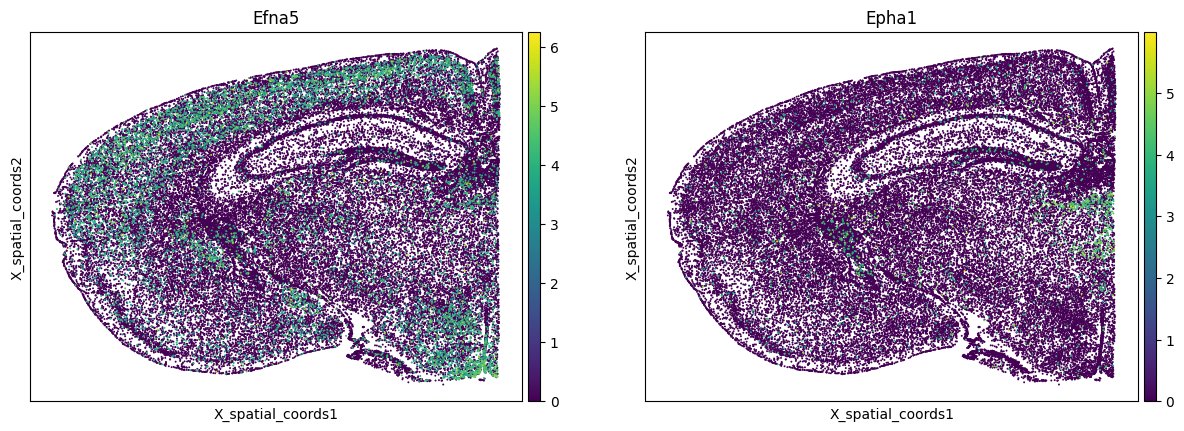

In [23]:
sc.pl.embedding(
    adata,
    basis="X_spatial_coords",
    color=[ligand, receptor],
    s=8,
    use_raw=False
)

------